In [40]:
!pip install requests pandas matplotlib fpdf validators beautifulsoup4 --quiet

import requests
import pandas as pd
import matplotlib.pyplot as plt
from fpdf import FPDF
from datetime import datetime
import time
import validators
import os
from bs4 import BeautifulSoup
import numpy as np

In [53]:
def normalize_url(url):
    url = url.strip()
    
    if not url.startswith("http://") and not url.startswith("https://"):
        url = "https://" + url
    
    if validators.url(url):
        return url
    else:
        return None

In [42]:
urls_input = input("Unesite web sajtove odvojene zarezom:\n")
raw_urls = [url.strip() for url in urls_input.split(",") if url.strip() != ""]

urls = []
invalid_urls = []

for url in raw_urls:
    normalized = normalize_url(url)
    if normalized:
        urls.append(normalized)
    else:
        invalid_urls.append(url)

print(f"\nValidni URL-ovi:\n{urls}")

if invalid_urls:
    print(f"\nNevalidni URL-ovi (preskočeni):\n{invalid_urls}")

Unesite web sajtove odvojene zarezom:
 google.com, github.com, gigatron.rs, sasaassas.com



Validni URL-ovi:
['https://google.com', 'https://github.com', 'https://gigatron.rs', 'https://sasaassas.com']


In [43]:
def check_website(url, timeout=5):
    result = {"URL": url, "Status Code": None, "Response Time (s)": None, "Status": None}
    try:
        start = time.time()
        response = requests.get(url, timeout=timeout)
        end = time.time()
        
        result["Status Code"] = response.status_code
        result["Response Time (s)"] = round(end - start, 3)
        
        if response.status_code == 200:
            result["Status"] = "UP"
        elif response.status_code == 404:
            result["Status"] = "NOT FOUND"
        elif response.status_code >= 500:
            result["Status"] = "SERVER ERROR"
        else:
            result["Status"] = "UNKNOWN"
    except requests.exceptions.Timeout:
        result["Status"] = "DOWN (Timeout)"
    except requests.exceptions.RequestException:
        result["Status"] = "DOWN (Error)"
    
    return result

results = []

for url in urls:
    res = check_website(url)
    results.append(res)
    print(f"{res['URL']}: {res['Status']} ({res['Status Code']}) - {res['Response Time (s)']}s")

df_results = pd.DataFrame(results)
df_results

https://google.com: UP (200) - 0.724s
https://github.com: UP (200) - 0.214s
https://gigatron.rs: UP (200) - 0.083s
https://sasaassas.com: DOWN (Error) (None) - Nones


,URL,Status Code,Response Time (s),Status
0,https://google.com,200.0,0.724,UP
1,https://github.com,200.0,0.214,UP
2,https://gigatron.rs,200.0,0.083,UP
3,https://sasaassas.com,NaN,NaN,DOWN (Error)


In [44]:
def calculate_score(row):
    # Ako nema response time → loš score
    if pd.isna(row['Response Time (s)']) or row['Response Time (s)'] == 0:
        return 0
    
    base_score = (1 / row['Response Time (s)']) * 100
    
    # Penalizacija
    if row['Status'] != "UP":
        base_score *= 0.3  # veliki penal za greške
    
    return round(base_score, 2)

# Dodavanje score kolone
df_results['Performance Score'] = df_results.apply(calculate_score, axis=1)

# Ranking (veći score = bolji)
df_results = df_results.sort_values(by='Performance Score', ascending=False).reset_index(drop=True)

print("\n🏆 PERFORMANCE RANKING:")
display(df_results[['URL', 'Status', 'Response Time (s)', 'Performance Score']])


🏆 PERFORMANCE RANKING:


,URL,Status,Response Time (s),Performance Score
0,https://gigatron.rs,UP,0.083,1204.82
1,https://github.com,UP,0.214,467.29
2,https://google.com,UP,0.724,138.12
3,https://sasaassas.com,DOWN (Error),NaN,0.00


In [45]:
HISTORY_FILE = "history.csv"

def save_history(df):
    df_copy = df.copy()
    df_copy["Timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if os.path.exists(HISTORY_FILE):
        df_copy.to_csv(HISTORY_FILE, mode='a', header=False, index=False)
    else:
        df_copy.to_csv(HISTORY_FILE, index=False)

save_history(df_results)
print("📁 Istorija sačuvana")

📁 Istorija sačuvana


In [46]:
def load_history():
    if os.path.exists(HISTORY_FILE):
        df_hist = pd.read_csv(HISTORY_FILE)
        df_hist["Timestamp"] = pd.to_datetime(df_hist["Timestamp"])
        return df_hist
    else:
        print("Nema istorije još.")
        return pd.DataFrame()

df_history = load_history()
df_history.head()

,URL,Status Code,Response Time (s),Status,Performance Score,Timestamp
0,https://gigatron.rs,200.0,0.079,UP,1265.82,2026-04-07 16:22:45
1,https://github.com,200.0,0.197,UP,507.61,2026-04-07 16:22:45
2,https://google.com,200.0,0.566,UP,176.68,2026-04-07 16:22:45
3,https://sasaassas.com,NaN,NaN,DOWN (Error),0.00,2026-04-07 16:22:45
4,https://gigatron.rs,200.0,0.083,UP,1204.82,2026-04-07 16:27:02


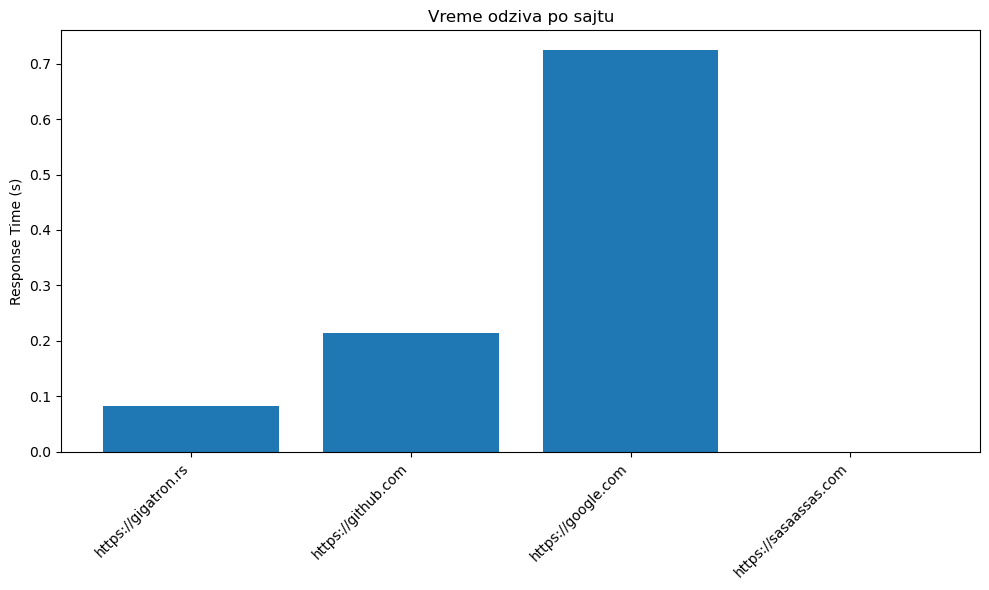

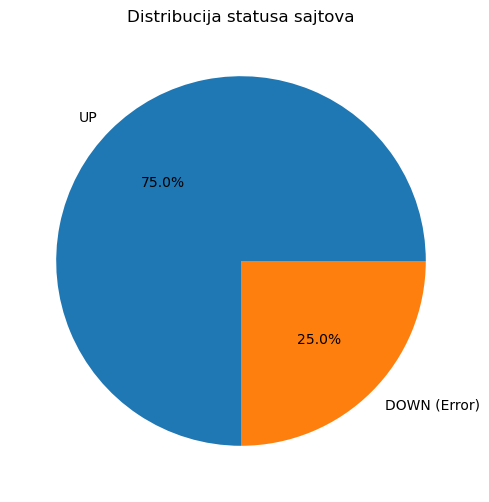

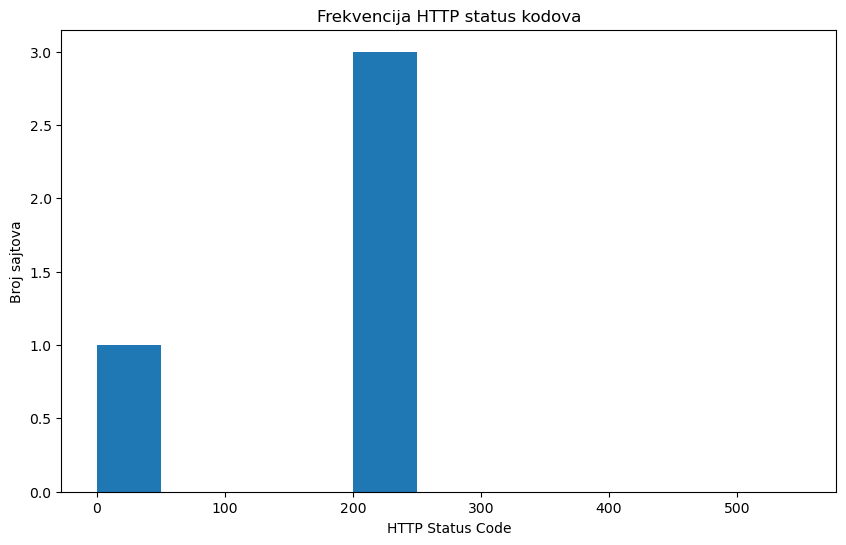

In [47]:
os.makedirs("charts", exist_ok=True)

# Bar chart
plt.figure(figsize=(10,6))
plt.bar(df_results['URL'], df_results['Response Time (s)'].fillna(0))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Response Time (s)')
plt.title('Vreme odziva po sajtu')
plt.tight_layout()
bar_path = "charts/bar_chart.png"
plt.savefig(bar_path)
plt.show()

# Pie chart
status_counts = df_results['Status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Distribucija statusa sajtova')
pie_path = "charts/pie_chart.png"
plt.savefig(pie_path)
plt.show()

# Histogram
plt.figure(figsize=(10,6))
status_codes = df_results['Status Code'].fillna(0)
plt.hist(status_codes, bins=range(0, 600, 50))
plt.xlabel('HTTP Status Code')
plt.ylabel('Broj sajtova')
plt.title('Frekvencija HTTP status kodova')
hist_path = "charts/hist_chart.png"
plt.savefig(hist_path)
plt.show()

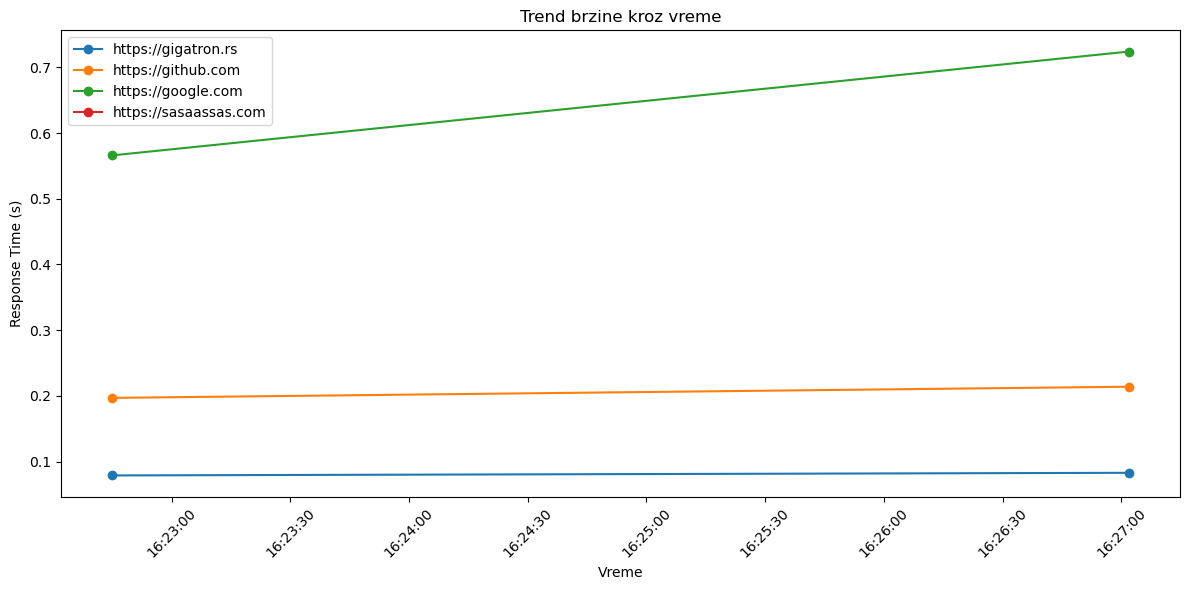

In [48]:
def plot_trend(df_history):
    if df_history.empty:
        print("Nema podataka za trend.")
        return None
    
    plt.figure(figsize=(12,6))
    
    for url in df_history['URL'].unique():
        df_url = df_history[df_history['URL'] == url].sort_values("Timestamp")
        plt.plot(df_url["Timestamp"], df_url["Response Time (s)"], marker='o', label=url)
    
    plt.xlabel("Vreme")
    plt.ylabel("Response Time (s)")
    plt.title("Trend brzine kroz vreme")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    trend_path = "charts/trend_chart.png"
    plt.savefig(trend_path)
    plt.show()
    
    return trend_path

trend_chart_path = plot_trend(df_history)

In [49]:
def calculate_trend(df_history):
    trends = []

    for url in df_history['URL'].unique():
        df_url = df_history[df_history['URL'] == url].sort_values("Timestamp")
        
        if len(df_url) < 2:
            trend = "Nedovoljno podataka"
        else:
            first = df_url.iloc[0]['Response Time (s)']
            last = df_url.iloc[-1]['Response Time (s)']
            
            if last < first:
                trend = "🚀 Poboljšanje"
            elif last > first:
                trend = "🐢 Pogoršanje"
            else:
                trend = "➖ Nema promene"
        
        trends.append({"URL": url, "Trend": trend})
    
    return pd.DataFrame(trends)

df_trends = calculate_trend(df_history)

print("\n📈 TREND ANALIZA:")
display(df_trends)


📈 TREND ANALIZA:


,URL,Trend
0,https://gigatron.rs,🐢 Pogoršanje
1,https://github.com,🐢 Pogoršanje
2,https://google.com,🐢 Pogoršanje
3,https://sasaassas.com,➖ Nema promene


In [50]:
def generate_pdf(df, filename="report.pdf"):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    
    pdf.set_font("Arial", "B", 16)
    pdf.cell(0, 10, "Website Status Report", ln=True, align='C')
    
    pdf.set_font("Arial", "", 12)
    pdf.cell(0, 10, f"Date & Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", ln=True, align='C')
    pdf.ln(10)
    
    pdf.set_font("Arial", "B", 10)
    col_width = pdf.w / 5.5
    
    pdf.cell(col_width, 10, "URL", 1)
    pdf.cell(col_width, 10, "Status Code", 1)
    pdf.cell(col_width, 10, "Response Time", 1)
    pdf.cell(col_width, 10, "Status", 1)
    pdf.cell(col_width, 10, "Score", 1)
    pdf.ln()
    
    pdf.set_font("Arial", "", 9)
    for _, row in df.iterrows():
        pdf.cell(col_width, 10, str(row['URL'])[:25], 1)
        pdf.cell(col_width, 10, str(row['Status Code']), 1)
        pdf.cell(col_width, 10, str(row['Response Time (s)']), 1)
        pdf.cell(col_width, 10, str(row['Status']), 1)
        pdf.cell(col_width, 10, str(row['Performance Score']), 1)
        pdf.ln()
    
    # Charts
    pdf.add_page()
    pdf.set_font("Arial", "B", 14)
    pdf.cell(0, 10, "Charts:", ln=True)
    
    pdf.image(bar_path, w=180)
    pdf.ln(5)
    pdf.image(pie_path, w=150)
    pdf.ln(5)
    pdf.image(hist_path, w=180)
    
    # Trend chart
    if trend_chart_path:
        pdf.add_page()
        pdf.cell(0, 10, "Trend kroz vreme:", ln=True)
        pdf.image(trend_chart_path, w=180)
    
    # Trend tekst
    pdf.ln(10)
    pdf.set_font("Arial", "", 10)
    for _, row in df_trends.iterrows():
        pdf.cell(0, 10, f"{row['URL']} -> {row['Trend']}", ln=True)
    
    pdf.output(filename)
    print(f"\nPDF '{filename}' kreiran!")

In [51]:
choice = input("Da li želite da generišete PDF izveštaj? (yes/no): ").strip().lower()

if choice == "yes":
    generate_pdf(df_results, filename="website_report.pdf")

Da li želite da generišete PDF izveštaj? (yes/no):  no


In [52]:
#cuvanje u istoriji kada se sajt pokrece i posle toga grafik i tabela koja pokazuju
#da li se neki sajt brze otvara ili ne u odnosu na prosli put

